# 🏦 Customer Churn Prediction - Bank Customers

## Project Objective

The objective of this project is to identify bank customers who are likely to leave the bank.

Customer churn means when a customer stops using the bank's services or closes their relationship with the bank.

In this project, we will:

- Load and understand the dataset
- Clean and prepare the data
- Encode categorical features like Geography and Gender
- Perform Exploratory Data Analysis with graphs
- Train classification models
- Evaluate models using Accuracy, Confusion Matrix, Precision, Recall, F1-score, ROC-AUC, MAE and RMSE
- Analyze feature importance
- Save the best model for dashboard usage
- Summarize key insights and business recommendations

## Dataset Description

This project uses a bank customer churn dataset.

The target column is:

- `Exited = 0` → Customer did not churn
- `Exited = 1` → Customer churned

Important columns:

- `CreditScore`
- `Geography`
- `Gender`
- `Age`
- `Tenure`
- `Balance`
- `NumOfProducts`
- `HasCrCard`
- `IsActiveMember`
- `EstimatedSalary`
- `Exited`

In [1]:
# Basic libraries
import json
import math
import warnings
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import joblib

# Preprocessing and model pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Train-test split
from sklearn.model_selection import train_test_split

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error
)

# Feature importance for models without built-in importance
from sklearn.inspection import permutation_importance

# Ignore unnecessary warnings
warnings.filterwarnings("ignore")

# Set graph style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# This cell handles paths safely whether notebook runs from project root or notebooks folder

current_path = Path.cwd()

if (current_path / "data" / "raw" / "train.csv").exists():
    ROOT_DIR = current_path
else:
    ROOT_DIR = current_path.parent

DATA_PATH = ROOT_DIR / "data" / "raw" / "train.csv"
TEST_PATH = ROOT_DIR / "data" / "raw" / "test.csv"

MODELS_DIR = ROOT_DIR / "models"
OUTPUTS_DIR = ROOT_DIR / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"

MODEL_PATH = MODELS_DIR / "churn_model.pkl"
METRICS_PATH = OUTPUTS_DIR / "metrics.json"
FEATURE_IMPORTANCE_PATH = OUTPUTS_DIR / "feature_importance.csv"
SUBMISSION_PATH = OUTPUTS_DIR / "submission.csv"

# Create folders if they do not exist
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root:", ROOT_DIR)
print("Train Data Path:", DATA_PATH)
print("Test Data Path:", TEST_PATH)

Project Root: d:\Customer_Churn_Prediction
Train Data Path: d:\Customer_Churn_Prediction\data\raw\train.csv
Test Data Path: d:\Customer_Churn_Prediction\data\raw\test.csv


In [3]:
# Load training dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (165034, 14)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


## Dataset Understanding

In this section, we inspect the dataset structure, column names, data types, missing values, duplicate records, and target distribution.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Number of rows: 165034
Number of columns: 14

Column Names:
['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [5]:
# Check data types and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  str    
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  str    
 5   Gender           165034 non-null  str    
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), str(3)
memory usage: 20.4 MB


In [6]:
# Statistical summary of numerical columns
df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [7]:
# Check missing values in each column
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing Values:")
missing_values

Missing Values:


id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [9]:
# Target distribution
target_counts = df["Exited"].value_counts()
target_percentage = df["Exited"].value_counts(normalize=True) * 100

print("Target Counts:")
print(target_counts)

print("\nTarget Percentage:")
print(target_percentage)

Target Counts:
Exited
0    130113
1     34921
Name: count, dtype: int64

Target Percentage:
Exited
0    78.840118
1    21.159882
Name: proportion, dtype: float64


## Data Cleaning and Preparation

The dataset is cleaned using the following steps:

- Remove duplicate rows
- Fill missing numerical values using median
- Fill missing categorical values using mode
- Create readable churn status labels for visualization

In [10]:
# Target column
TARGET_COLUMN = "Exited"

# Numerical features
numeric_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
]

# Categorical features
categorical_features = ["Geography", "Gender"]

# Columns that are not useful for model training
identifier_columns = ["id", "CustomerId", "Surname"]

print("Numerical Features:", numeric_features)
print("Categorical Features:", categorical_features)
print("Identifier Columns:", identifier_columns)

Numerical Features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categorical Features: ['Geography', 'Gender']
Identifier Columns: ['id', 'CustomerId', 'Surname']


In [11]:
# Create a copy of the original dataset
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Fill missing numerical values with median
for col in numeric_features:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing categorical values with mode
for col in categorical_features:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Create readable churn status column
df_clean["Churn_Status"] = df_clean[TARGET_COLUMN].map({
    0: "Not Churned",
    1: "Churned"
})

print("Cleaned dataset shape:", df_clean.shape)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

df_clean.head()

Cleaned dataset shape: (165034, 15)

Missing values after cleaning:
id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
Churn_Status       0
dtype: int64


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Churn_Status
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0,Not Churned
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0,Not Churned
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0,Not Churned
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0,Not Churned
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0,Not Churned


## Exploratory Data Analysis

Exploratory Data Analysis helps us understand customer behavior and identify patterns related to churn.

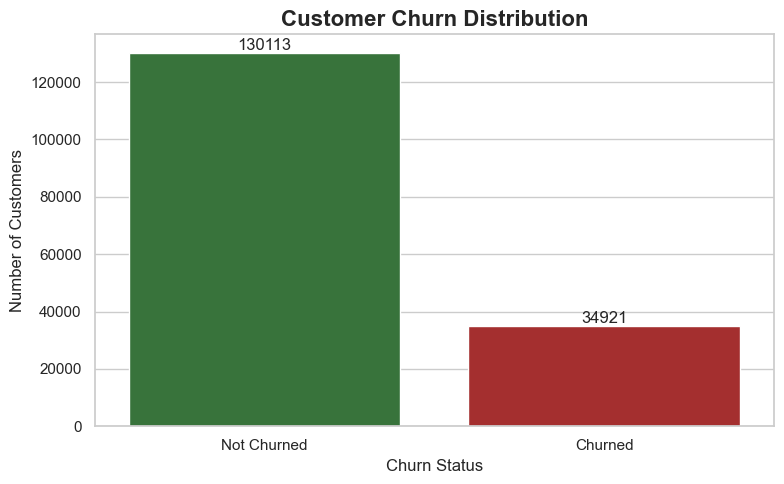

In [12]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df_clean,
    x="Churn_Status",
    palette=["#2E7D32", "#B71C1C"]
)

plt.title("Customer Churn Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_01_churn_distribution.png", dpi=300)
plt.show()

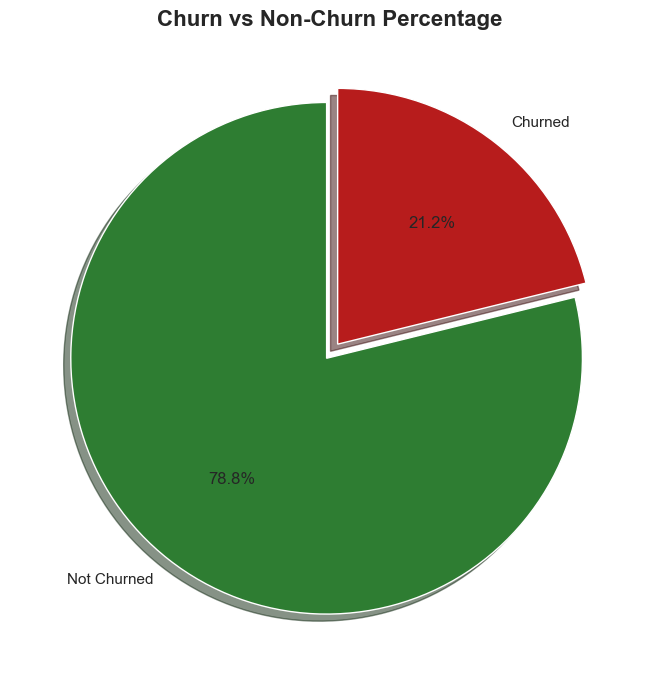

In [13]:
churn_counts = df_clean["Churn_Status"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2E7D32", "#B71C1C"],
    explode=[0.02, 0.05],
    shadow=True
)

plt.title("Churn vs Non-Churn Percentage", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_02_churn_pie.png", dpi=300)
plt.show()

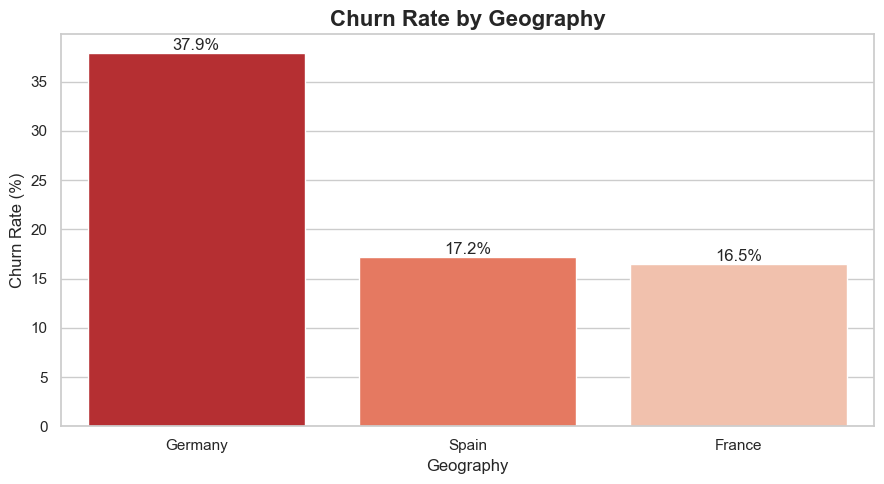

In [14]:
geo_churn = (
    df_clean.groupby("Geography")[TARGET_COLUMN]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=geo_churn,
    x="Geography",
    y=TARGET_COLUMN,
    palette="Reds_r"
)

plt.title("Churn Rate by Geography", fontsize=16, fontweight="bold")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_03_churn_rate_by_geography.png", dpi=300)
plt.show()

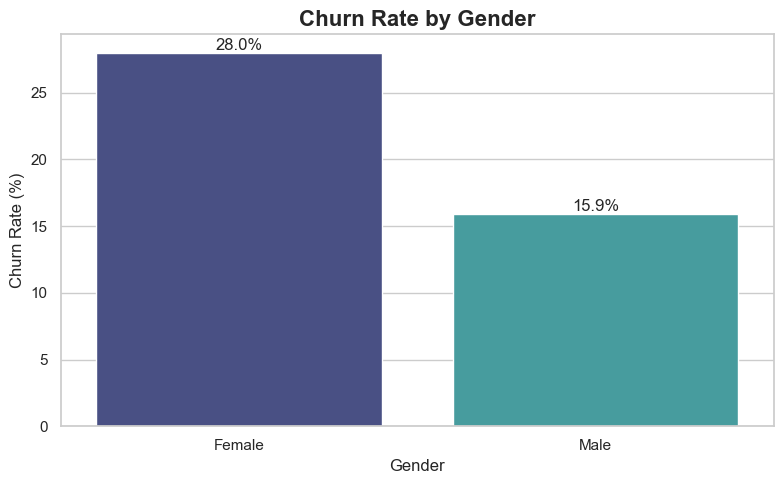

In [15]:
gender_churn = (
    df_clean.groupby("Gender")[TARGET_COLUMN]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=gender_churn,
    x="Gender",
    y=TARGET_COLUMN,
    palette="mako"
)

plt.title("Churn Rate by Gender", fontsize=16, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_04_churn_rate_by_gender.png", dpi=300)
plt.show()

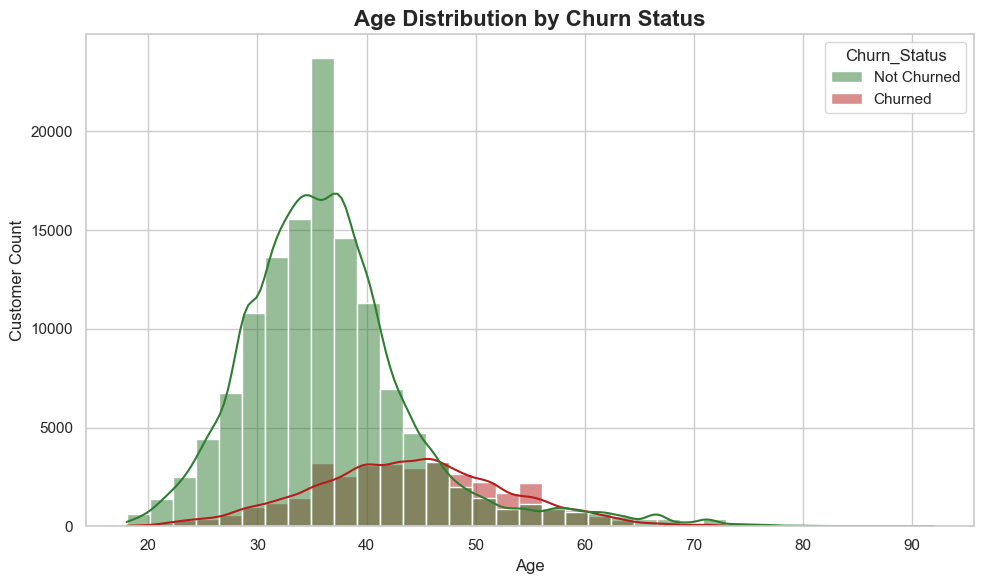

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="Age",
    hue="Churn_Status",
    bins=35,
    kde=True,
    palette=["#2E7D32", "#B71C1C"]
)

plt.title("Age Distribution by Churn Status", fontsize=16, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Customer Count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_05_age_distribution_by_churn.png", dpi=300)
plt.show()

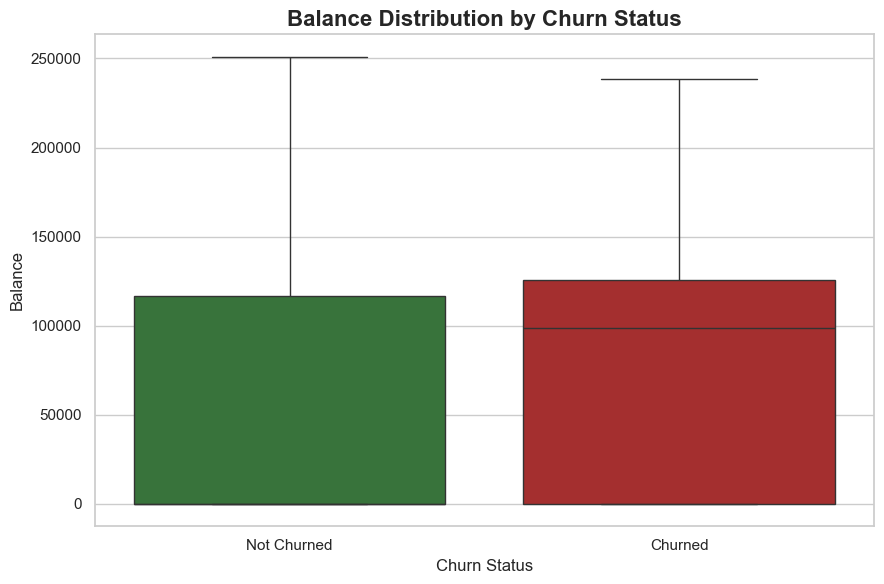

In [17]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="Churn_Status",
    y="Balance",
    palette=["#2E7D32", "#B71C1C"]
)

plt.title("Balance Distribution by Churn Status", fontsize=16, fontweight="bold")
plt.xlabel("Churn Status")
plt.ylabel("Balance")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_06_balance_distribution_by_churn.png", dpi=300)
plt.show()

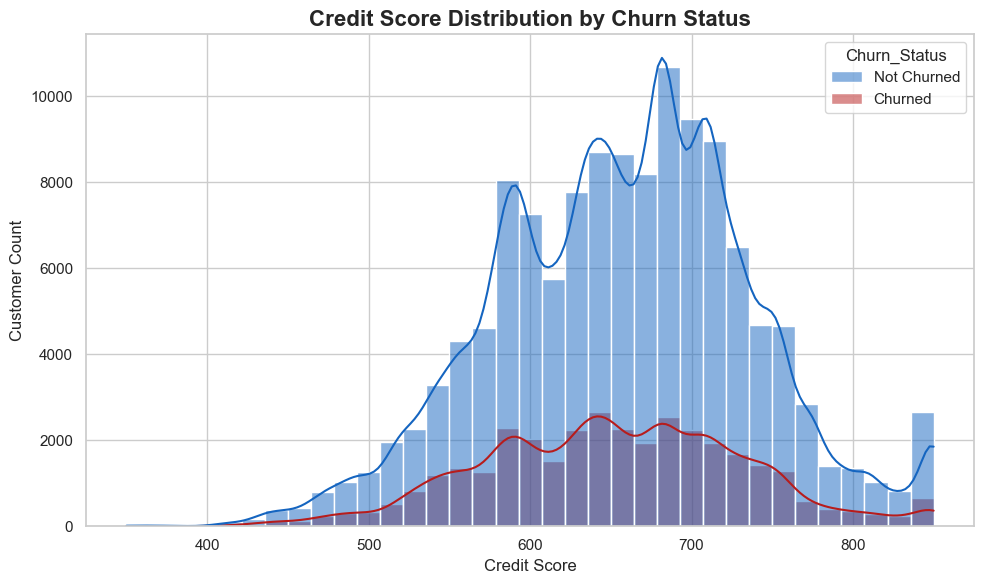

In [18]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="CreditScore",
    hue="Churn_Status",
    bins=35,
    kde=True,
    palette=["#1565C0", "#B71C1C"]
)

plt.title("Credit Score Distribution by Churn Status", fontsize=16, fontweight="bold")
plt.xlabel("Credit Score")
plt.ylabel("Customer Count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_07_credit_score_distribution.png", dpi=300)
plt.show()

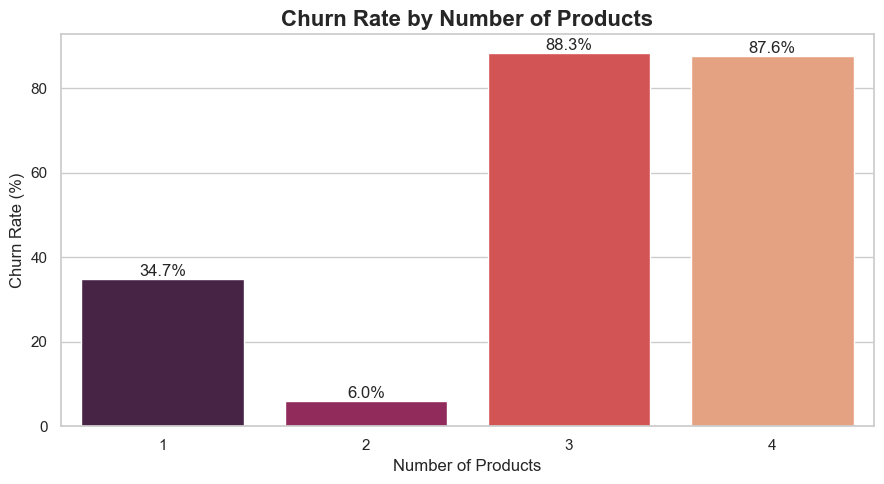

In [19]:
product_churn = (
    df_clean.groupby("NumOfProducts")[TARGET_COLUMN]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=product_churn,
    x="NumOfProducts",
    y=TARGET_COLUMN,
    palette="rocket"
)

plt.title("Churn Rate by Number of Products", fontsize=16, fontweight="bold")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_08_churn_rate_by_products.png", dpi=300)
plt.show()

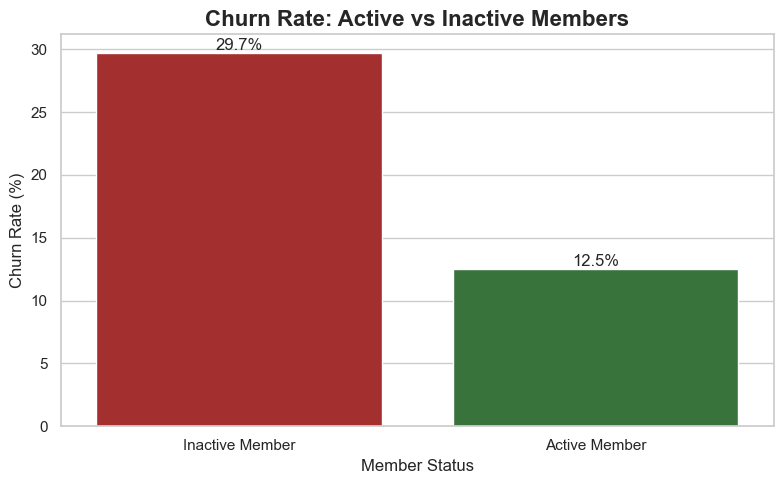

In [20]:
active_churn = (
    df_clean.groupby("IsActiveMember")[TARGET_COLUMN]
    .mean()
    .mul(100)
    .reset_index()
)

active_churn["Member_Status"] = active_churn["IsActiveMember"].map({
    0.0: "Inactive Member",
    1.0: "Active Member",
    0: "Inactive Member",
    1: "Active Member"
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=active_churn,
    x="Member_Status",
    y=TARGET_COLUMN,
    palette=["#B71C1C", "#2E7D32"]
)

plt.title("Churn Rate: Active vs Inactive Members", fontsize=16, fontweight="bold")
plt.xlabel("Member Status")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_09_active_member_churn.png", dpi=300)
plt.show()

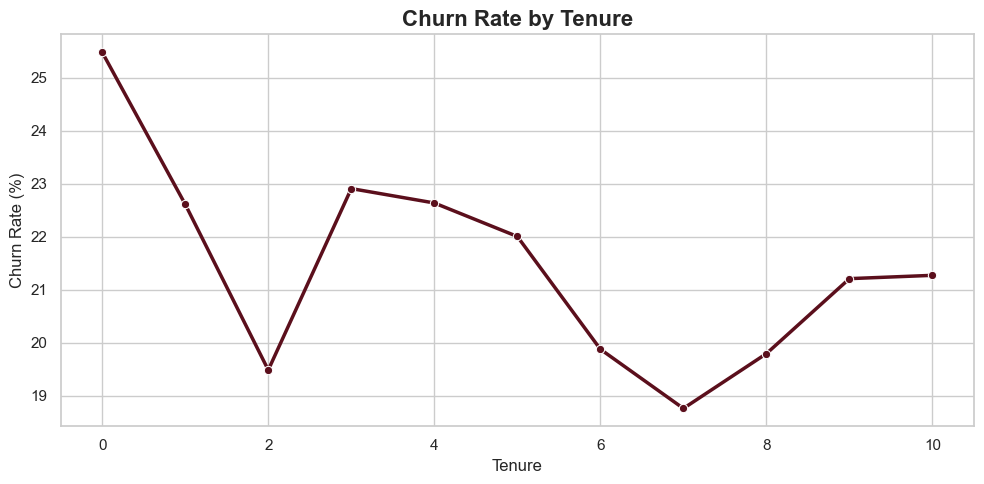

In [21]:
tenure_churn = (
    df_clean.groupby("Tenure")[TARGET_COLUMN]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=tenure_churn,
    x="Tenure",
    y=TARGET_COLUMN,
    marker="o",
    linewidth=2.5,
    color="#5b0f1c"
)

plt.title("Churn Rate by Tenure", fontsize=16, fontweight="bold")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_10_churn_rate_by_tenure.png", dpi=300)
plt.show()

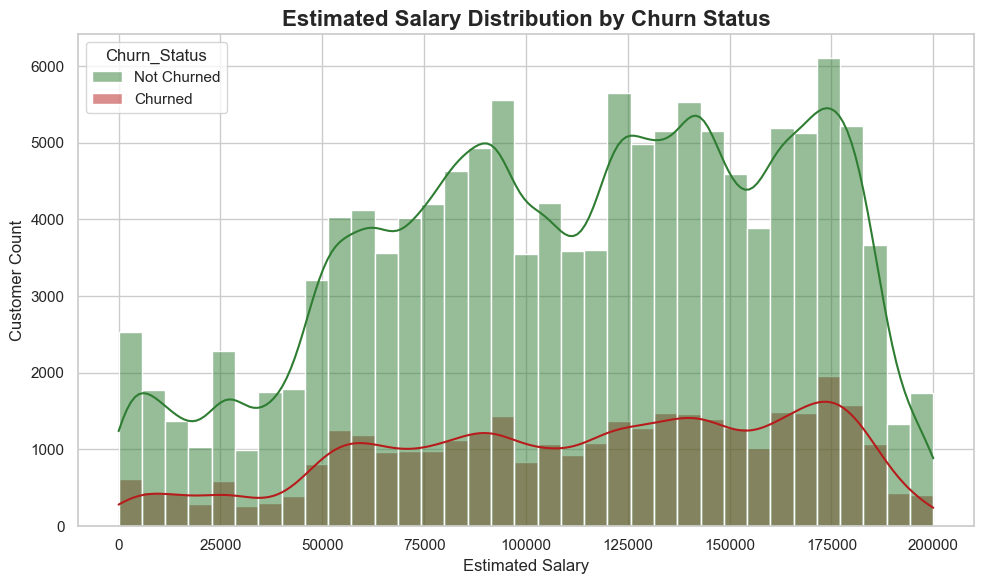

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="EstimatedSalary",
    hue="Churn_Status",
    bins=35,
    kde=True,
    palette=["#2E7D32", "#B71C1C"]
)

plt.title("Estimated Salary Distribution by Churn Status", fontsize=16, fontweight="bold")
plt.xlabel("Estimated Salary")
plt.ylabel("Customer Count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_11_salary_distribution.png", dpi=300)
plt.show()

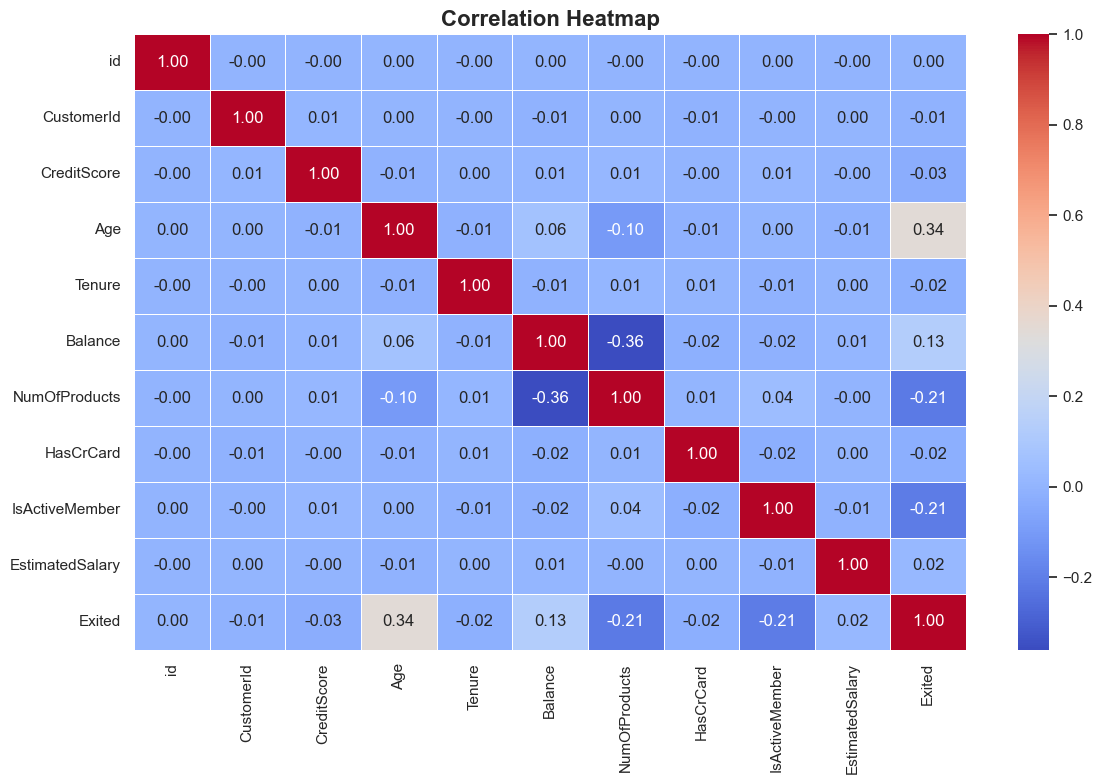

In [23]:
numeric_df = df_clean.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_12_correlation_heatmap.png", dpi=300)
plt.show()

## Feature Engineering and Encoding

Machine learning models cannot directly understand text values like `Geography` and `Gender`.

So we use:

- `StandardScaler` for numerical features
- `OneHotEncoder` for categorical features
- `ColumnTransformer` to apply preprocessing in a clean pipeline

In [24]:
# Drop target column and extra churn label column
X = df_clean.drop(columns=[TARGET_COLUMN, "Churn_Status"])

# Target variable
y = df_clean[TARGET_COLUMN]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

X.head()

Feature data shape: (165034, 13)
Target data shape: (165034,)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83


In [25]:
def create_one_hot_encoder():
    """
    This function supports both old and new versions of scikit-learn.
    New versions use sparse_output=False.
    Older versions use sparse=False.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

In [26]:
def build_preprocessor():
    """
    Build preprocessing pipeline:
    - StandardScaler for numerical columns
    - OneHotEncoder for categorical columns
    """
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", create_one_hot_encoder(), categorical_features),
        ],
        remainder="drop",
        sparse_threshold=0
    )
    
    return preprocessor


# Show sample preprocessor
build_preprocessor()

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``"

In [27]:
# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Validation data shape:", X_valid.shape)
print("Training target shape:", y_train.shape)
print("Validation target shape:", y_valid.shape)

Training data shape: (132027, 13)
Validation data shape: (33007, 13)
Training target shape: (132027,)
Validation target shape: (33007,)


## Model Training and Testing

We train multiple supervised classification models:

1. Logistic Regression
2. Random Forest
3. Extra Trees
4. Hist Gradient Boosting

The best model will be selected using ROC-AUC score because the dataset is imbalanced.

In [28]:
def find_best_threshold(y_true, y_proba):
    """
    Find the best probability threshold using F1 score.
    
    Default threshold is 0.50, but churn data is imbalanced.
    Threshold tuning helps improve churn classification.
    """
    thresholds = np.arange(0.25, 0.76, 0.01)

    best_threshold = 0.50
    best_f1 = -1

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        score = f1_score(y_true, y_pred)

        if score > best_f1:
            best_f1 = score
            best_threshold = threshold

    return round(float(best_threshold), 2)

In [29]:
def evaluate_model(model, X_valid, y_valid):
    """
    Evaluate model using classification metrics.
    """
    # Predicted churn probability
    y_proba = model.predict_proba(X_valid)[:, 1]

    # Find best threshold
    best_threshold = find_best_threshold(y_valid, y_proba)

    # Convert probabilities into final classes
    y_pred = (y_proba >= best_threshold).astype(int)

    # Calculate MAE and RMSE on probabilities
    mse_value = mean_squared_error(y_valid, y_proba)
    rmse_value = math.sqrt(mse_value)

    metrics = {
        "optimal_threshold": best_threshold,
        "accuracy": round(float(accuracy_score(y_valid, y_pred)), 4),
        "precision": round(float(precision_score(y_valid, y_pred)), 4),
        "recall": round(float(recall_score(y_valid, y_pred)), 4),
        "f1_score": round(float(f1_score(y_valid, y_pred)), 4),
        "roc_auc": round(float(roc_auc_score(y_valid, y_proba)), 4),
        "mae_probability": round(float(mean_absolute_error(y_valid, y_proba)), 4),
        "rmse_probability": round(float(rmse_value), 4),
        "confusion_matrix": confusion_matrix(y_valid, y_pred).tolist(),
        "classification_report": classification_report(y_valid, y_pred, output_dict=True),
    }

    return metrics

In [30]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=18,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight=None,
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=350,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight=None,
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=350,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.05,
        early_stopping=True,
        validation_fraction=0.10,
        random_state=42,
    ),
}

print("Models defined successfully!")

Models defined successfully!


In [31]:
all_metrics = {}
trained_models = {}

best_name = None
best_score = -1
best_pipeline = None

for name, model in models.items():
    print("=" * 70)
    print(f"Training Model: {name}")
    print("=" * 70)

    # Create pipeline with fresh preprocessor for each model
    pipeline = Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("model", model),
        ]
    )

    # Train model
    pipeline.fit(X_train, y_train)

    # Evaluate model
    metrics = evaluate_model(pipeline, X_valid, y_valid)

    all_metrics[name] = metrics
    trained_models[name] = pipeline

    print("Optimal Threshold:", metrics["optimal_threshold"])
    print("Accuracy:", metrics["accuracy"])
    print("Precision:", metrics["precision"])
    print("Recall:", metrics["recall"])
    print("F1 Score:", metrics["f1_score"])
    print("ROC-AUC:", metrics["roc_auc"])
    print("MAE Probability:", metrics["mae_probability"])
    print("RMSE Probability:", metrics["rmse_probability"])

    # Select best model using ROC-AUC
    if metrics["roc_auc"] > best_score:
        best_score = metrics["roc_auc"]
        best_name = name
        best_pipeline = pipeline

print("\nBest Model:", best_name)
print("Best ROC-AUC:", best_score)

Training Model: Logistic Regression
Optimal Threshold: 0.59
Accuracy: 0.7976
Precision: 0.5176
Recall: 0.6406
F1 Score: 0.5726
ROC-AUC: 0.8159
MAE Probability: 0.3485
RMSE Probability: 0.4142
Training Model: Random Forest
Optimal Threshold: 0.31
Accuracy: 0.8443
Precision: 0.6158
Recall: 0.7026
F1 Score: 0.6564
ROC-AUC: 0.8831
MAE Probability: 0.2016
RMSE Probability: 0.317
Training Model: Extra Trees
Optimal Threshold: 0.33
Accuracy: 0.8489
Precision: 0.6316
Recall: 0.686
F1 Score: 0.6577
ROC-AUC: 0.8839
MAE Probability: 0.215
RMSE Probability: 0.3185
Training Model: Hist Gradient Boosting
Optimal Threshold: 0.34
Accuracy: 0.8565
Precision: 0.6572
Recall: 0.6725
F1 Score: 0.6648
ROC-AUC: 0.8896
MAE Probability: 0.1966
RMSE Probability: 0.3129

Best Model: Hist Gradient Boosting
Best ROC-AUC: 0.8896


## Model Comparison

The trained models are compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- MAE Probability
- RMSE Probability

In [32]:
comparison_df = pd.DataFrame([
    {
        "Model": model_name,
        "Optimal Threshold": metrics["optimal_threshold"],
        "Accuracy": metrics["accuracy"],
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1 Score": metrics["f1_score"],
        "ROC-AUC": metrics["roc_auc"],
        "MAE Probability": metrics["mae_probability"],
        "RMSE Probability": metrics["rmse_probability"],
    }
    for model_name, metrics in all_metrics.items()
])

comparison_df = comparison_df.sort_values(by="ROC-AUC", ascending=False)

comparison_df

,Model,Optimal Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,MAE Probability,RMSE Probability
3,Hist Gradient Boosting,0.34,0.8565,0.6572,0.6725,0.6648,0.8896,0.1966,0.3129
2,Extra Trees,0.33,0.8489,0.6316,0.6860,0.6577,0.8839,0.2150,0.3185
1,Random Forest,0.31,0.8443,0.6158,0.7026,0.6564,0.8831,0.2016,0.3170
0,Logistic Regression,0.59,0.7976,0.5176,0.6406,0.5726,0.8159,0.3485,0.4142


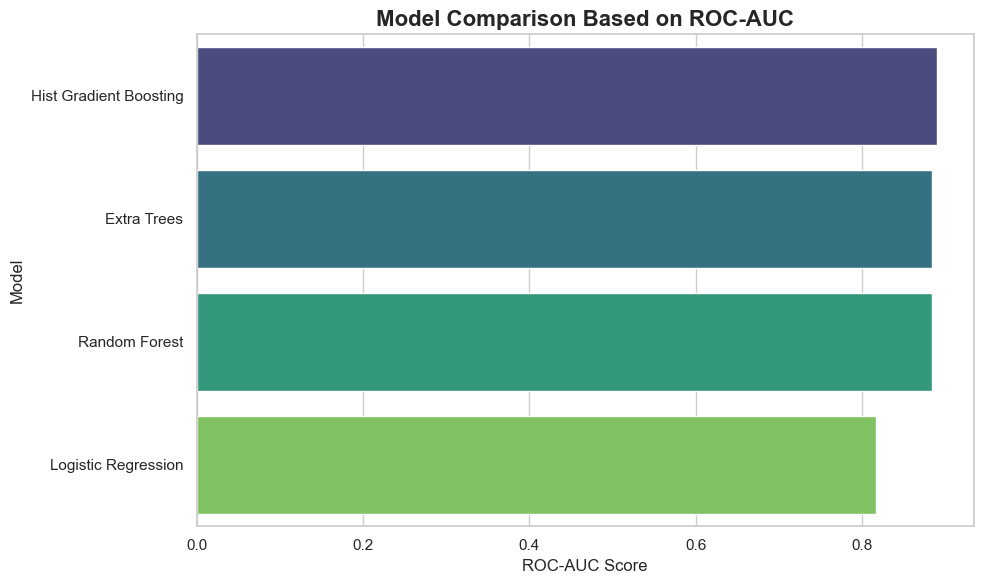

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_df,
    x="ROC-AUC",
    y="Model",
    palette="viridis"
)

plt.title("Model Comparison Based on ROC-AUC", fontsize=16, fontweight="bold")
plt.xlabel("ROC-AUC Score")
plt.ylabel("Model")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_13_model_comparison.png", dpi=300)
plt.show()

## Best Model Evaluation

The best model is selected based on the highest ROC-AUC score.

ROC-AUC is useful because the churn dataset is imbalanced, meaning the number of non-churned customers is higher than churned customers.

In [34]:
best_metrics = all_metrics[best_name]

print("Best Model:", best_name)
print("Optimal Threshold:", best_metrics["optimal_threshold"])
print("Accuracy:", best_metrics["accuracy"])
print("Precision:", best_metrics["precision"])
print("Recall:", best_metrics["recall"])
print("F1 Score:", best_metrics["f1_score"])
print("ROC-AUC:", best_metrics["roc_auc"])
print("MAE Probability:", best_metrics["mae_probability"])
print("RMSE Probability:", best_metrics["rmse_probability"])

Best Model: Hist Gradient Boosting
Optimal Threshold: 0.34
Accuracy: 0.8565
Precision: 0.6572
Recall: 0.6725
F1 Score: 0.6648
ROC-AUC: 0.8896
MAE Probability: 0.1966
RMSE Probability: 0.3129


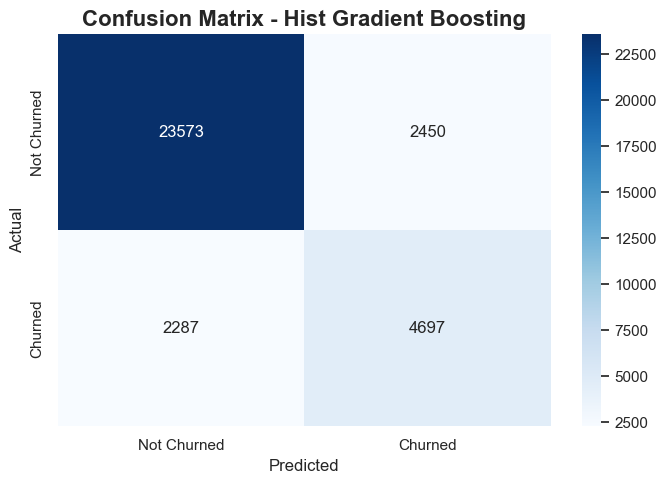

In [35]:
cm = np.array(best_metrics["confusion_matrix"])

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churned", "Churned"],
    yticklabels=["Not Churned", "Churned"],
)

plt.title(f"Confusion Matrix - {best_name}", fontsize=16, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_14_confusion_matrix.png", dpi=300)
plt.show()

In [36]:
# Get predictions using best threshold
y_proba_best = best_pipeline.predict_proba(X_valid)[:, 1]
best_threshold = best_metrics["optimal_threshold"]

y_pred_best = (y_proba_best >= best_threshold).astype(int)

print("Classification Report:")
print(classification_report(y_valid, y_pred_best))

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     26023
           1       0.66      0.67      0.66      6984

    accuracy                           0.86     33007
   macro avg       0.78      0.79      0.79     33007
weighted avg       0.86      0.86      0.86     33007



## Feature Importance

Feature importance helps us understand which customer attributes influence churn prediction the most.

For models like Random Forest and Extra Trees, built-in feature importance is used.

For Hist Gradient Boosting, permutation importance is used.

In [37]:
best_model_object = best_pipeline.named_steps["model"]
best_preprocessor = best_pipeline.named_steps["preprocessor"]

model_class_name = best_model_object.__class__.__name__

print("Best model class:", model_class_name)

if hasattr(best_model_object, "feature_importances_"):
    # Feature names after preprocessing
    cat_encoder = best_preprocessor.named_transformers_["cat"]
    categorical_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
    final_feature_names = numeric_features + categorical_names

    importance_values = best_model_object.feature_importances_

    importance_df = pd.DataFrame({
        "feature": final_feature_names,
        "importance": importance_values
    }).sort_values(by="importance", ascending=False)

elif hasattr(best_model_object, "coef_"):
    # For Logistic Regression
    cat_encoder = best_preprocessor.named_transformers_["cat"]
    categorical_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
    final_feature_names = numeric_features + categorical_names

    importance_values = abs(best_model_object.coef_[0])

    importance_df = pd.DataFrame({
        "feature": final_feature_names,
        "importance": importance_values
    }).sort_values(by="importance", ascending=False)

else:
    # For Hist Gradient Boosting, use permutation importance
    print("Using permutation importance for this model...")

    sample_size = min(5000, len(X_valid))
    X_sample = X_valid.sample(sample_size, random_state=42)
    y_sample = y_valid.loc[X_sample.index]

    result = permutation_importance(
        best_pipeline,
        X_sample,
        y_sample,
        n_repeats=3,
        random_state=42,
        scoring="roc_auc",
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "feature": X_sample.columns,
        "importance": result.importances_mean
    }).sort_values(by="importance", ascending=False)

# Save feature importance
importance_df.to_csv(FEATURE_IMPORTANCE_PATH, index=False)

importance_df.head(15)

Best model class: HistGradientBoostingClassifier
Using permutation importance for this model...


,feature,importance
9,NumOfProducts,0.143750
6,Age,0.084803
11,IsActiveMember,0.029453
8,Balance,0.028574
4,Geography,0.016844
5,Gender,0.007224
3,CreditScore,0.002270
10,HasCrCard,0.001083
12,EstimatedSalary,0.000859
7,Tenure,0.000408


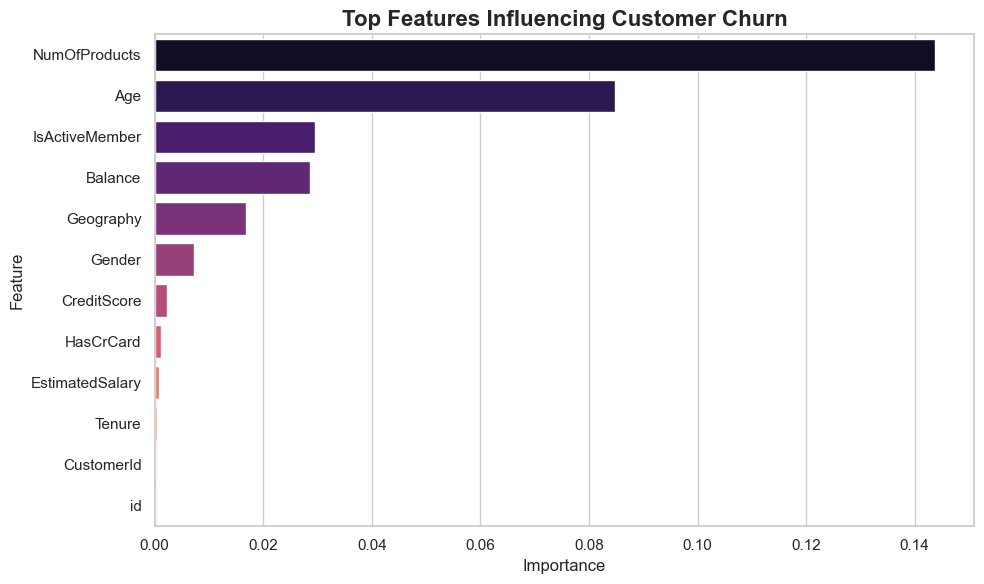

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df.head(12),
    x="importance",
    y="feature",
    palette="magma"
)

plt.title("Top Features Influencing Customer Churn", fontsize=16, fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_15_feature_importance.png", dpi=300)
plt.show()

## Save Best Model and Metrics

The best trained model is saved so it can be used later in the Streamlit dashboard for customer churn prediction.

In [39]:
# Save best model
joblib.dump(best_pipeline, MODEL_PATH)

# Save metrics
final_metrics = {
    "best_model": best_name,
    "all_model_metrics": all_metrics
}

with open(METRICS_PATH, "w") as f:
    json.dump(final_metrics, f, indent=4)

print("Model saved at:", MODEL_PATH)
print("Metrics saved at:", METRICS_PATH)
print("Feature importance saved at:", FEATURE_IMPORTANCE_PATH)

Model saved at: d:\Customer_Churn_Prediction\models\churn_model.pkl
Metrics saved at: d:\Customer_Churn_Prediction\outputs\metrics.json
Feature importance saved at: d:\Customer_Churn_Prediction\outputs\feature_importance.csv


## Test Prediction on a Single Customer

Now we test the saved model on one sample customer from the validation dataset.

In [40]:
sample_customer = X_valid.iloc[[0]]

churn_probability = best_pipeline.predict_proba(sample_customer)[0][1]
prediction = 1 if churn_probability >= best_threshold else 0

print("Churn Probability:", round(churn_probability * 100, 2), "%")
print("Prediction:", "Churned" if prediction == 1 else "Not Churned")

sample_customer

Churn Probability: 8.27 %
Prediction: Not Churned


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
47555,47555,15656901,Hs?,590,France,Male,44.0,8,0.0,2,1.0,0.0,87067.73


## Create Submission File

The test dataset does not contain the target column.  
We use the trained model to generate churn probability predictions for the test data.

In [41]:
if TEST_PATH.exists():
    test_df = pd.read_csv(TEST_PATH)

    # Fill missing values in test data
    for col in numeric_features:
        if col in test_df.columns:
            test_df[col] = test_df[col].fillna(test_df[col].median())

    for col in categorical_features:
        if col in test_df.columns:
            test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

    # Predict churn probability
    test_proba = best_pipeline.predict_proba(test_df)[:, 1]

    submission = pd.DataFrame({
        "id": test_df["id"],
        "Exited": test_proba
    })

    submission.to_csv(SUBMISSION_PATH, index=False)

    print("Submission file saved at:", SUBMISSION_PATH)
    submission.head()

else:
    print("test.csv file not found.")

Submission file saved at: d:\Customer_Churn_Prediction\outputs\submission.csv


## Key Insights

From EDA and model results, we observed that:

1. Customer age has a strong relationship with churn.
2. Inactive members are more likely to churn.
3. Number of products is an important factor in customer churn.
4. Geography affects churn behavior.
5. Balance and credit score provide useful information for prediction.
6. Hist Gradient Boosting performed best among all trained models.

## Conclusion

This project successfully predicts customer churn using machine learning.

The dataset was cleaned, categorical features were encoded, EDA graphs were created, and multiple supervised classification models were trained.

The best model was Hist Gradient Boosting, which achieved strong performance on validation data.

This model can help banks identify high-risk customers early and take retention actions such as:

- Personalized offers
- Loyalty rewards
- Better customer support
- Special packages for inactive customers
- Customer engagement campaigns

The final trained model is saved and can be used in the Streamlit dashboard for interactive churn prediction.